# Проект: Система антифрода транзакций для цифрового ритейла

---

# Инфромация об источнике и составе данных, а также EDA содержатся в предыдущем шаге проекта: [EDA](EDA.ipynb)

# Выбранные метрики качества
*   **Основная метрика:** PR-AUC (Average Precision) — площадь под кривой Precision-Recall, идеальна для сильного дисбаланса классов. В данном датасете 2 класса: фрод/не фрод, ~3.5% — доля фрода.
*   **Контрольная метрика:** False Positive Rate (FPR) — мониторинг доли ложных блокировок честных транзакций. Данная метрика необходима, так как большая доля ложных блокировок негативно скажется на прибыльньности бизнеса и лояльности клиентов.

# Загрузка и оптимизация данных

In [1]:
# Ячейка для импорта всех библиотек, используемых в данном ноутбуке
import json
from pathlib import Path
import random
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_recall_curve, auc, confusion_matrix
import itertools 
import matplotlib.pyplot as plt
import seaborn as sns



# Глобальный сид для Python и NumPy
random.seed(42)
np.random.seed(42)

In [2]:
def memory_optimization(df, max_diff_threshold=0.01):
    """
    Оптимизирует типы данных, но защищает колонки от искажения точности.
    Если при переводе во float16 разница превышает max_diff_threshold,
    колонка переводится во float32.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    protected_cols = [] # Список колонок, которые мы защитили от float16
    
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            # Обработка целых чисел (здесь потерь точности не бывает)
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            
            # Обработка чисел с плавающей точкой (Float)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    # Тестируем перевод во float16
                    test_cast = df[col].astype(np.float16)
                    # Считаем максимальное отклонение от исходных данных
                    # fillna(0) защищает от ошибок сравнения NaN
                    diff = np.abs(df[col].fillna(0).values - test_cast.fillna(0).values).max()
                    
                    if diff <= max_diff_threshold:
                        df[col] = test_cast
                    else:
                        # Если округление слишком грубое — переводим во float32
                        df[col] = df[col].astype(np.float32)
                        protected_cols.append((col, diff))
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
                    
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Память уменьшена на {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    if protected_cols:
        print(f"\nЗащищено от искажения {len(protected_cols)} колонок (оставлен float32):")
        for col, diff in protected_cols:
            print(f"  - {col}: возможная потеря точности была {diff:.4f} (> {max_diff_threshold})")
            
    return df


def verify_memory_optimization(df_before_sample, df_after, threshold=0.01):
    """
    Проверяет, что финальные данные не имеют искажений выше порога threshold.
    """
    df_after_sample = df_after.loc[df_before_sample.index]
    num_cols = df_before_sample.select_dtypes(include=[np.number]).columns
    mismatched_num = 0
    
    for col in num_cols:
        before_vals = df_before_sample[col].fillna(0).values
        after_vals = df_after_sample[col].fillna(0).values
        
        if np.issubdtype(df_before_sample[col].dtype, np.integer):
            is_close = np.array_equal(before_vals, after_vals)
        else:
            # проверка по порогу 0.01
            is_close = np.allclose(before_vals, after_vals, atol=threshold)
            
        if not is_close:
            mismatched_num += 1
            max_diff = np.abs(before_vals - after_vals).max()
            print(f"Обнаружено недопустимое расхождение в {col}! Разница: {max_diff:.4f}")
            
    if mismatched_num == 0:
        print(f"Шаг 1: Все численные признаки совпадают (отклонения строго <= {threshold})")
    else:
        print(f"Шаг 1: Найдено {mismatched_num} колонок с нарушением точности.")

    # 2. Проверка категорий
    obj_cols = df_before_sample.select_dtypes(include=['object']).columns
    mismatched_obj = 0
    for col in obj_cols:
        if not df_before_sample[col].equals(df_after_sample[col]):
            mismatched_obj += 1
            print(f"Ошибка в категориальной колонке: {col}")
            
    if mismatched_obj == 0:
        print("Шаг 2: Все категориальные признаки идентичны на 100%")
        
    print(f"Верификация завершена.")


In [3]:
# загрузка
df = pd.read_csv('data/df_raw.csv')

# сохраняем 100 строк до оптимизации
before_sample = df.sample(100, random_state=42).copy()

# оптимизация
transaction = memory_optimization(df)

# верификация
verify_memory_optimization(before_sample, transaction)

Память уменьшена на 64.3%

Защищено от искажения 45 колонок (оставлен float32):
  - TransactionAmt: возможная потеря точности была 1.9700 (> 0.01)
  - dist1: возможная потеря точности была 2.0000 (> 0.01)
  - dist2: возможная потеря точности была 3.0000 (> 0.01)
  - C1: возможная потеря точности была 2.0000 (> 0.01)
  - C2: возможная потеря точности была 2.0000 (> 0.01)
  - C4: возможная потеря точности была 1.0000 (> 0.01)
  - C6: возможная потеря точности была 1.0000 (> 0.01)
  - C7: возможная потеря точности была 1.0000 (> 0.01)
  - C8: возможная потеря точности была 1.0000 (> 0.01)
  - C10: возможная потеря точности была 1.0000 (> 0.01)
  - C11: возможная потеря точности была 1.0000 (> 0.01)
  - C12: возможная потеря точности была 1.0000 (> 0.01)
  - C13: возможная потеря точности была 1.0000 (> 0.01)
  - D8: возможная потеря точности была 0.5000 (> 0.01)
  - V129: возможная потеря точности была 11.0000 (> 0.01)
  - V130: возможная потеря точности была 11.0000 (> 0.01)
  - V131: во

In [4]:
df.shape

(590540, 436)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 436 entries, TransactionID to has_identity
dtypes: float16(311), float32(90), int16(1), int32(2), int8(1), object(31)
memory usage: 698.9+ MB


In [6]:
with pd.option_context('display.max_columns', None):
    display(df.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,has_R_email,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,

# Первичное обучение и отбор признаков

Из-за большого количества признаков (400+) применяется метод предварительной фильтрации признаков на полном датасете.

**Алгоритм отбора:**
1. **Добавления фичей:** В пул признаков добавляются `hour`, `day_of_week` , `has_identity` и `has_R_email`, так как в ходе EDA было доказано их существенное влияние на таргетную переменную.
2. **Фильтрация по Feature Importance:** Обучается CatBoostClassifier, после чего на основе встроенной метрики важности (Feature Importance) отбираются топ-100 наиболее информативных признаков.

**Результат:** Данный шаг позволяет очистить пространство от "шумящих" и константных признаков (особенно из избыточной группы V), сокращая время обучения при проверке сгенирированных новых признаков без значительной потери качества.

In [7]:
def run_catboost_base(df, features_list):
    """
    Обучение CatBoost и расчет бизнес-метрик.
    
    Параметры:
    - df: датасет для обучения модели (должен содержать 'TransactionDT')
    - features_list: список признаков, на которых обучаем модель
    """
    # Константы
    TARGET_COL = 'isFraud'
    TIME_COL = 'TransactionDT'
    
    # Создаем локальную копию данных, чтобы избежать побочных эффектов для исходного df
    df_working = df.copy()
    
    # Гарантируем хронологическую сортировку перед делением
    df_working = df_working.sort_values(TIME_COL).reset_index(drop=True)
    
    # Исключаем служебные колонки из обучения, если они попали в список
    drop_cols = [TARGET_COL, TIME_COL, 'TransactionID']
    features = [col for col in features_list if col not in drop_cols]
    
    # Автоматически определяем категории
    cat_features = df_working[features].select_dtypes(include=['object', 'category']).columns.tolist()
            
    # Переводим категории в строковый тип и заполняем NaN (требование CatBoost)
    for col in cat_features:
        df_working[col] = df_working[col].astype(str).fillna('nan')

    # Хронологический сплит (80/20)
    split_idx = int(len(df_working) * 0.8)
    
    X_train = df_working[features].iloc[:split_idx]
    y_train = df_working[TARGET_COL].iloc[:split_idx]
    
    X_val = df_working[features].iloc[split_idx:]
    y_val = df_working[TARGET_COL].iloc[split_idx:]
    
    print(f"Обучение на {X_train.shape[1]} признаках (из них {len(cat_features)} категориальных)...")
    
    # Обучение CatBoost
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    model = CatBoostClassifier(
        iterations=400,             # Ограничиваем для быстрой итерации
        learning_rate=0.08,
        depth=6,
        auto_class_weights='Balanced', # Компенсируем дисбаланс 3.5% фрода
        random_seed=42,
        boost_from_average=False,  # Запрещает модели динамически вычислять среднее по таргету для старта
        has_time=True,             # Подсказывает CatBoost, что данные упорядочены во времени (запрещает случайный выбор фичей по батчам)
        verbose=100                  # Печатать лог каждые 100 деревьев
    )
    
    print("\nЗапуск CatBoost...")
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)
    
    # Расчет метрик PR-AUC и FPR
    preds_proba = model.predict_proba(X_val)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y_val, preds_proba)
    pr_auc_score = auc(recall, precision)
    
    # Расчет FPR при стандартном бизнес-пороге (например, P > 0.5) 
    # Переводим вероятности в жесткие классы (0 или 1) по дефолтному порогу 0.5
    preds_class = (preds_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds_class).ravel()
    fpr_default = fp / (fp + tn)
    
    # Продвинутый расчет: ищем порог, чтобы поймать ровно 80% фрода (Recall = 80%)
    target_recall = 0.80
    idx = np.where(recall >= target_recall)[0][-1] # Находим индекс, где Recall максимально близок к 80%
    best_threshold = thresholds[idx]

    # Считаем FPR для этого оптимального порога
    preds_class_80 = (preds_proba >= best_threshold).astype(int)
    tn_80, fp_80, fn_80, tp_80 = confusion_matrix(y_val, preds_class_80).ravel()
    fpr_at_80_recall = fp_80 / (fp_80 + tn_80)
    
    print("\n=== МЕТРИКИ ЭКСПЕРИМЕНТА ===")
    print(f"PR-AUC: {pr_auc_score:.4f}")
    print(f"FPR при стандартном пороге 0.5: {fpr_default:.2%}")
    print(f"FPR при удержании 80% фрода (Recall=80%): {fpr_at_80_recall:.2%}")
    print(f"Оптимальный порог для Recall=80%: {best_threshold:.4f}")
    
    metrics = {
        'pr_auc': pr_auc_score,
        'fpr_05': fpr_default,
        'fpr_80': fpr_at_80_recall,
        'threshold_80': best_threshold
    }
    
    return model, metrics

In [8]:
# Добавляем час и день недели (условные). has_identity и has_R_email были добавлены ранее, на этапе EDA 
df = df.assign(
    hour = lambda x: ((x['TransactionDT'] // 3600) % 24).astype('category'),
    day_of_week = lambda x: ((x['TransactionDT'] // 86400) % 7).astype('category')
)


In [9]:
df.shape

(590540, 438)

In [10]:
# запуск на всём датасете
# из обучения убираются 3 колонки: таргет, TransactionDT и TransactionID
model_base, metrics_base = run_catboost_base(df, df.columns)

Обучение на 435 признаках (из них 33 категориальных)...

Запуск CatBoost...
0:	learn: 0.6577941	test: 0.6581594	best: 0.6581594 (0)	total: 1.01s	remaining: 6m 43s
100:	learn: 0.3907131	test: 0.4270647	best: 0.4270647 (100)	total: 1m 15s	remaining: 3m 43s
200:	learn: 0.3485719	test: 0.4057800	best: 0.4057800 (200)	total: 2m 31s	remaining: 2m 29s
300:	learn: 0.3138027	test: 0.3938480	best: 0.3938339 (297)	total: 3m 47s	remaining: 1m 14s
399:	learn: 0.2903662	test: 0.3897819	best: 0.3897819 (399)	total: 5m 3s	remaining: 0us

bestTest = 0.3897818668
bestIteration = 399


=== МЕТРИКИ ЭКСПЕРИМЕНТА ===
PR-AUC: 0.5075
FPR при стандартном пороге 0.5: 9.93%
FPR при удержании 80% фрода (Recall=80%): 14.16%
Оптимальный порог для Recall=80%: 0.4133


In [11]:
# Отбор ТОП-100 признаков по Feature Importance
drop_cols = ['isFraud', 'TransactionDT', 'TransactionID']
features = [col for col in df.columns if col not in drop_cols]

importance = model_base.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Сохраняем список топ-100 фичей
top_100_features = fi_df.head(100)['Feature'].tolist()

print(f"\n Топ-100 признаков успешно сформированы.")
print(f"\n Топ-10 признаков.")
display(fi_df.head(10)) # топ-15 самых сильных признаков



 Топ-100 признаков успешно сформированы.

 Топ-10 признаков.


,Feature,Importance
3,card2,5.037662
14,C1,4.575675
27,C14,4.441776
26,C13,4.439098
2,card1,4.204257
0,TransactionAmt,2.980403
8,addr1,2.522639
29,D2,2.491776
24,C11,2.363382
19,C6,2.345540


In [12]:
# топ-100 фичей
print(top_100_features)

['card2', 'C1', 'C14', 'C13', 'card1', 'TransactionAmt', 'addr1', 'D2', 'C11', 'C6', 'DeviceInfo', 'P_emaildomain', 'M4', 'card6', 'D15', 'C2', 'D1', 'M6', 'D10', 'card5', 'M5', 'C5', 'card3', 'V258', 'C10', 'V91', 'ProductCD', 'C9', 'dist1', 'R_emaildomain', 'V308', 'V285', 'V70', 'C4', 'V294', 'D8', 'hour', 'V317', 'id_31', 'V232', 'V310', 'V30', 'V243', 'V281', 'V67', 'V312', 'V82', 'V90', 'V62', 'V54', 'D4', 'card4', 'D11', 'C8', 'V283', 'V187', 'V61', 'V69', 'V306', 'V165', 'V200', 'V83', 'id_02', 'V53', 'V133', 'V49', 'id_20', 'D5', 'V87', 'V315', 'V314', 'V201', 'id_33', 'DeviceType', 'V219', 'V296', 'V56', 'M3', 'V38', 'C3', 'V76', 'V99', 'V242', 'V75', 'C12', 'V264', 'V48', 'V23', 'V128', 'V20', 'V202', 'V29', 'V12', 'D3', 'id_17', 'V295', 'id_03', 'V316', 'M8', 'V189']


### Анализ метрик

* **Анализ логов обучения:**
    * Наблюдается значительный разрыв между ошибкой на обучающей выборке (`learn Logloss: 0.29`) и отложенной валидации (`test Logloss: 0.39`), что говорит о переобучении. Модель слишком сильно заучила особенности старых транзакций и поэтому хуже справляется с новыми.
    * `bestIteration = 399`, говорит о том, что заданных 400 итераций не достаточно и в дальнейшем необходимо повышать лимит.
* **PR-AUC (0.5075):** Демонстрирует неплохую базовую способность модели разделять классы. В данной задаче с сильным дисбалансом классов (где фрода ~3.5%) случайная модель выдавала бы  PR-AUC, равный доле целевого класса — то есть 0.035. Текущий результат PR-AUC = 0.5075 превышает показатели случайного угадывания более чем в 14 раз.
* **FPR при стандартном пороге 0.5 (9.93%):** При стандартных настройках классификации система генерирует неприемлемый уровень ложных срабатываний. Блокировка 9.93%% легитимного трафика финансово разрушительна для SME-бизнеса.
* **Recall=80% -> FPR=14.16%:** При попытке перехватить 80% мошеннических транзакций модель снижает порог отсечения до **0.4133**. При этом в категорию "подозрительных" попадает 14.16% честных покупателей.

**Выводы:**
* Необхолимо дальнейшее улучшение модели.
* Текущая метрика FPR (9.93% ложных блокировок) является коммерчески неприемлемой для SME-сегмента. В дальнейшем необходимо зафиксировать FPR <= 1%.

### Сопоставление результатов отбора признаков с выводами EDA

* **Подтверждение ключевых гипотез:** Признаки `hour`, `TransactionAmt`, `ProductCD`, `card4`, `card6`, `P_emaildomain` и `R_emaildomain`, которые на этапе EDA показали значительное влияние на таргет, вошли в топ-100. Это доказывает их высокую предсказательную силу.
* **Замещение дня недели:** Признак `day_of_week` не попал в первую сотню. При этом в топ пробилось несколько D-признаков. Скорее всего, временные дельты в этих колонках уже содержат в себе информацию о недельной сезонности, и модели этого оказалось достаточно.
* **Замещение флага Identity:** Синтетический признак `has_identity` также остался за пределами топ-100. Вместо него CatBoost отобрал детальные сырые параметры из таблицы устройств — в частности, `DeviceInfo` и несколько признаков `id_`. Модель предпочла работать с конкретными техническими маркерами (версиями ОС и браузеров), а не с их бинарным агрегатом.

**Вывод:** Машинный отбор подтвердил правильность векторов исследования из этапа EDA. 

---

# Логарифмирование суммы транзакции (`Amt_log`)

На предыдущем шаге было сокращено количество признаков до топ-100. Прежде чем переходить к усложнению модели, необходимо проверить приведет ли замена исходного признака суммы транзакции `TransactionAmt` на его логарифмированную версию к росту метрики PR-AUC при одновременном снижении FPR.
Также стоит отметить, что `TransactionAmt` попал на 6 место по важности влияния на таргетную переменную, что говорит о высокой значимости этого признака.

### Теоретическое обоснование

1. **Особенности работы бустинга с тяжелыми хвостами:**
   В сфере e-commerce для малого и среднего бизнеса (SME) распределение сумм транзакций имеет длинный правый хвост распределения. Огромная масса легитимных покупок сосредоточена в диапазоне от нескольких долларов до пары сотен, но присутствуют единичные операции на десятки тысяч долларов. 
   Алгоритм CatBoost по умолчанию квантует числовые признаки на фиксированное количество корзин. В сырых данных из-за огромного разброса сетка квантования сильно растягивается: алгоритм тратит ценные границы сплитов на описание редких крупных сумм в "хвосте", ухудшая детализацию в зоне мелких и средних чеков, где и скрывается основной объем SME-фрода.

2. **Физический смысл сжатия распределения:**
   Логарифмическая функция нелинейно сжимает масштаб: она «прижимает» гигантские выбросы ближе к основному массиву данных, но при этом растягивает расстояние между мелкими суммами. Разница между ＄5 и ＄15 становится для модели более значимой, чем разница между ＄10 005 и ＄10 015. 

3. **Защита от переобучения на уникальных суммах:**
   Сырой признак суммы с экстремальными значениями может провоцировать деревья решений строить глубокие изолированные ветки под конкретные уникальные сверхкрупные транзакции. Логарифм уберёт этот эффект, заставляя модель оценивать масштаб суммы более обобщенно.

---

## Визуализация распределения `TransactionAmt` и `Amt_log`

In [13]:
#  Создаем Amt_log 
df_exp = df.copy()
df_exp['Amt_log'] = np.log1p(df_exp['TransactionAmt']).astype('float32')

In [14]:
df_exp.shape

(590540, 439)

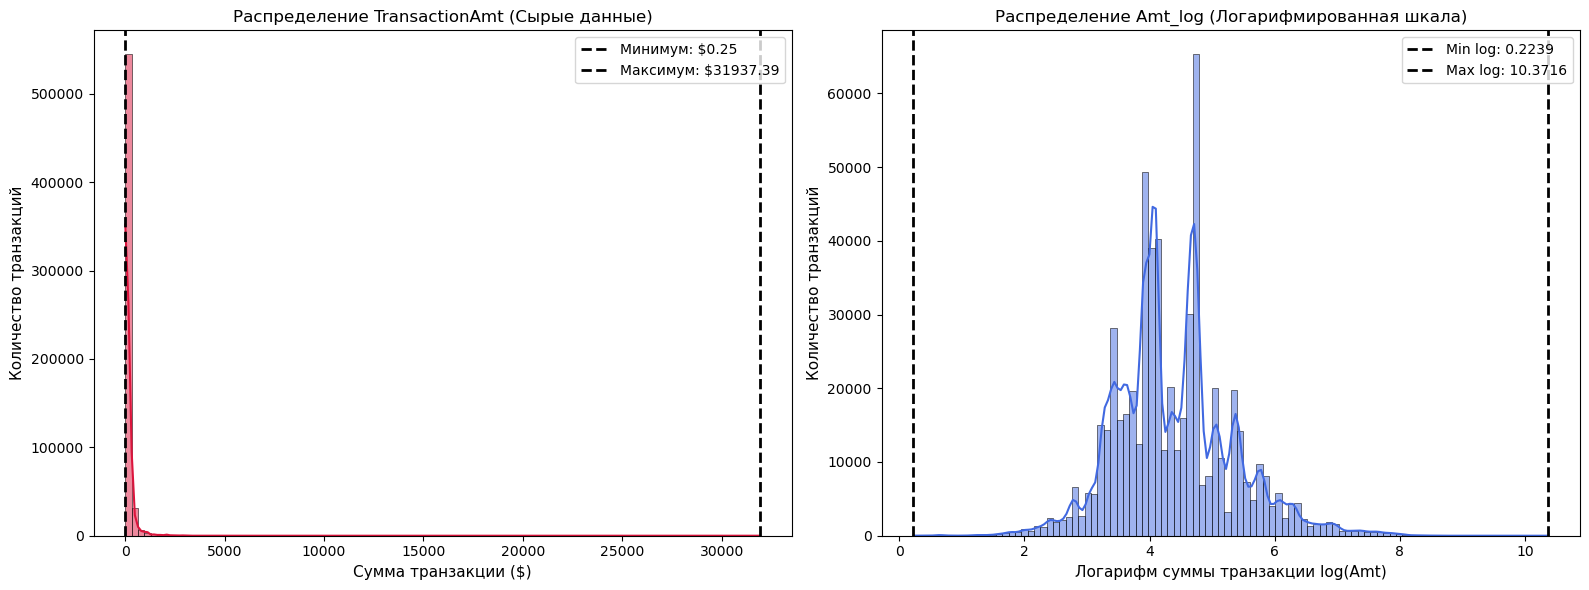

In [15]:
# 1. Создаем фигуру из двух графиков (1 строка, 2 колонки)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================================================================
# ЛЕВЫЙ ГРАФИК: Сырые данные
# =========================================================================

# Вычисляем экстремумы для сырых данных
amt_min = df['TransactionAmt'].min()
amt_max = df['TransactionAmt'].max()

# Строим гистограмму для сырых сумм транзакций
sns.histplot(
    data=df,
    x='TransactionAmt',
    bins=100,
    kde=True,
    color='crimson',
    ax=axes[0]
)

# Добавляем вертикальные линии-маркеры минимума и максимума
axes[0].axvline(amt_min, color='black', linestyle='--', linewidth=2, label=f'Минимум: ${amt_min:.2f}')
axes[0].axvline(amt_max, color='black', linestyle='--', linewidth=2, label=f'Максимум: ${amt_max:.2f}')
axes[0].legend(loc='upper right')

# Оформление левого графика
axes[0].set_title(
    f'Распределение TransactionAmt (Сырые данные)', 
    fontsize=12
)
axes[0].set_xlabel('Сумма транзакции ($)', fontsize=11)
axes[0].set_ylabel('Количество транзакций', fontsize=11)


# =========================================================================
# ПРАВЫЙ ГРАФИК: Логарифмированные данные 
# =========================================================================

# Вычисляем экстремумы для логарифмированных данных
log_min = df_exp['Amt_log'].min()
log_max = df_exp['Amt_log'].max()

# Строим гистограмму для нормализованной фичи Amt_log
sns.histplot(
    data=df_exp,
    x='Amt_log',
    bins=100,
    kde=True,
    color='royalblue',
    ax=axes[1]
)

# Добавляем вертикальные линии-маркеры для логарифма
axes[1].axvline(log_min, color='black', linestyle='--', linewidth=2, label=f'Min log: {log_min:.4f}')
axes[1].axvline(log_max, color='black', linestyle='--', linewidth=2, label=f'Max log: {log_max:.4f}')
axes[1].legend(loc='upper right')

# Оформление правого графика
axes[1].set_title(
    f'Распределение Amt_log (Логарифмированная шкала)', 
    fontsize=12
)
axes[1].set_xlabel('Логарифм суммы транзакции log(Amt)', fontsize=11)
axes[1].set_ylabel('Количество транзакций', fontsize=11)

# Автоматическое выравнивание отступов между графиками
plt.tight_layout()
plt.show()


###  Визуальный анализ распределения сумм транзакций до и после логарифмирования

На построенной визуализации наглядно продемонстрирована необходимость применения логарифмического преобразования суммы транзакций:

1. **Левый график (Сырые данные — `TransactionAmt`):**  
   Распределение сумм имеет классический вид экстремального тяжелого хвоста. Минимальное значение составляет всего `＄0.25`, а максимальное `＄31 937.39`. Подавляющая масса транзакций сосредоточена в узком диапазоне около нуля, из-за чего на графике виден лишь один тонкий вертикальный пик слева. 

2. **Правый график (Логарифмированная шкала — `Amt_log`):**  
   Применение логарифма полностью устранило проблему тяжелого хвоста, сжав диапазон данных в понятные границы (от `Min log: 0.2239` до `Max log: 10.3716`).

## Обучение на топ-100 признаках
Для начала посмотрим на качество обучения модели на топ-100 признаках. Используем исходный признак `TransactionAmt`.

In [16]:
# эксперимент на 100 отобранных признаках
model_exp_1, metrics_exp_1 = run_catboost_base(df, top_100_features)

Обучение на 100 признаках (из них 15 категориальных)...

Запуск CatBoost...
0:	learn: 0.6542329	test: 0.6545517	best: 0.6545517 (0)	total: 399ms	remaining: 2m 39s
100:	learn: 0.3868459	test: 0.4229153	best: 0.4229153 (100)	total: 35s	remaining: 1m 43s
200:	learn: 0.3448639	test: 0.4032838	best: 0.4032838 (200)	total: 1m 11s	remaining: 1m 10s
300:	learn: 0.3104737	test: 0.3948683	best: 0.3945856 (295)	total: 1m 47s	remaining: 35.4s
399:	learn: 0.2892238	test: 0.3906492	best: 0.3906134 (385)	total: 2m 23s	remaining: 0us

bestTest = 0.3906134009
bestIteration = 385

Shrink model to first 386 iterations.

=== МЕТРИКИ ЭКСПЕРИМЕНТА ===
PR-AUC: 0.4973
FPR при стандартном пороге 0.5: 10.35%
FPR при удержании 80% фрода (Recall=80%): 14.35%
Оптимальный порог для Recall=80%: 0.4174


## Обучение на топ-100 признаках, с заменой `TransactionAmt` на `Amt_log`
Те же топ-100 признаков, но теперь вместо `TransactionAmt` его логарифм - `Amt_log`.

In [17]:
#  меняем сумму транзакций на логарифм этих транзакций

top_100_features_log = list(top_100_features)

# Формируем новый список признаков на основе ТОП-100
# Находим и заменяем TransactionAmt на Amt_log

if 'TransactionAmt' in top_100_features_log:
    top_100_features_log.remove('TransactionAmt')
if 'Amt_log' not in top_100_features_log:
    top_100_features_log.append('Amt_log')

print(f"Количество признаков в списке: {len(top_100_features_log)}")

Количество признаков в списке: 100


In [18]:
df_exp.shape

(590540, 439)

In [19]:
print(top_100_features_log)

['card2', 'C1', 'C14', 'C13', 'card1', 'addr1', 'D2', 'C11', 'C6', 'DeviceInfo', 'P_emaildomain', 'M4', 'card6', 'D15', 'C2', 'D1', 'M6', 'D10', 'card5', 'M5', 'C5', 'card3', 'V258', 'C10', 'V91', 'ProductCD', 'C9', 'dist1', 'R_emaildomain', 'V308', 'V285', 'V70', 'C4', 'V294', 'D8', 'hour', 'V317', 'id_31', 'V232', 'V310', 'V30', 'V243', 'V281', 'V67', 'V312', 'V82', 'V90', 'V62', 'V54', 'D4', 'card4', 'D11', 'C8', 'V283', 'V187', 'V61', 'V69', 'V306', 'V165', 'V200', 'V83', 'id_02', 'V53', 'V133', 'V49', 'id_20', 'D5', 'V87', 'V315', 'V314', 'V201', 'id_33', 'DeviceType', 'V219', 'V296', 'V56', 'M3', 'V38', 'C3', 'V76', 'V99', 'V242', 'V75', 'C12', 'V264', 'V48', 'V23', 'V128', 'V20', 'V202', 'V29', 'V12', 'D3', 'id_17', 'V295', 'id_03', 'V316', 'M8', 'V189', 'Amt_log']


In [20]:
# Запускаем функцию 
model_exp_2, metrics_exp_2 = run_catboost_base(df_exp, top_100_features_log)

Обучение на 100 признаках (из них 15 категориальных)...

Запуск CatBoost...
0:	learn: 0.6545017	test: 0.6555294	best: 0.6555294 (0)	total: 389ms	remaining: 2m 35s
100:	learn: 0.3878305	test: 0.4246687	best: 0.4246687 (100)	total: 36s	remaining: 1m 46s
200:	learn: 0.3453766	test: 0.4017010	best: 0.4017010 (200)	total: 1m 11s	remaining: 1m 11s
300:	learn: 0.3117352	test: 0.3958403	best: 0.3954002 (289)	total: 1m 48s	remaining: 35.6s
399:	learn: 0.2889603	test: 0.3931869	best: 0.3931869 (399)	total: 2m 24s	remaining: 0us

bestTest = 0.3931868707
bestIteration = 399


=== МЕТРИКИ ЭКСПЕРИМЕНТА ===
PR-AUC: 0.4978
FPR при стандартном пороге 0.5: 9.93%
FPR при удержании 80% фрода (Recall=80%): 14.70%
Оптимальный порог для Recall=80%: 0.3994


In [21]:
# сотрировка ТОП-100 признаков по Feature Importance
importance = model_exp_2.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': top_100_features_log,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Сохраняем список топ-100 фичей
top_100_features_log = fi_df.head(100)['Feature'].tolist()

print(f"\n Топ-10 признаков.")
display(fi_df.head(10)) # топ-15 самых сильных признаков



 Топ-10 признаков.


,Feature,Importance
1,C1,5.998497
0,card2,5.149378
2,C14,5.047661
4,card1,4.422793
3,C13,4.011564
99,Amt_log,3.141082
5,addr1,2.736820
8,C6,2.414354
7,C11,2.373258
19,M5,2.141813


In [23]:
print(top_100_features_log)

['C1', 'card2', 'C14', 'card1', 'C13', 'Amt_log', 'addr1', 'C6', 'C11', 'M5', 'card6', 'C5', 'C2', 'D2', 'M4', 'DeviceInfo', 'V258', 'P_emaildomain', 'D15', 'D10', 'ProductCD', 'card5', 'M6', 'V283', 'R_emaildomain', 'D1', 'C8', 'id_31', 'dist1', 'V285', 'C9', 'V310', 'D4', 'V308', 'V53', 'V90', 'V70', 'V294', 'V87', 'D8', 'V29', 'V201', 'D11', 'card4', 'card3', 'V62', 'V165', 'C4', 'hour', 'D3', 'V242', 'V317', 'V312', 'V187', 'V219', 'V67', 'V281', 'V82', 'V69', 'C10', 'V315', 'V83', 'V54', 'V56', 'V61', 'V296', 'M3', 'id_02', 'id_17', 'V38', 'V30', 'V202', 'V99', 'id_20', 'id_03', 'V314', 'C12', 'id_33', 'V316', 'V76', 'V23', 'V75', 'V20', 'C3', 'V49', 'V133', 'V91', 'V12', 'M8', 'D5', 'V128', 'V48', 'DeviceType', 'V306', 'V189', 'V264', 'V295', 'V232', 'V243', 'V200']


### Сводная таблица результатов

| Эксперимент | PR-AUC (Ранжирование) | FPR (Порог 0.5) | Best Iteration |
| :--- | :---: | :---: | :---: |
| **топ-100** включая `TransactionAmt` | 0.4973 | 10.35% | 385 |
| **топ-100** включая `Amt_log` | 0.4978 | **9.93%** |  **399** |
| **Весь датасет**  | **0.5075** | **9.93%** | **399** |


###  Сравнение результатов обучения на полном и урезаном датасетах
Разница в качестве ранжирования между урезанным датасетом и полным составляет **~1%** (PR-AUC 0.4978 vs 0.5075). 
* **Причина:** На этапе Feature Importance были отобраны топ-100 самых сильных признаков. Однако в бустинге работает эффект синергии: сотни «слабых» признаков, каждый из которых вносит микроскопический вклад, в сумме дают модели ощутимый объем контекста. 
* **Вывод для архитектуры:** Разрыв всего в 1% означает, что топ-100 фичей — это отличный репрезентативный срез данных. Можно тестировать гипотезы и новые сложные агрегаты на урезанном датасете.

### Сравнение результатов обучения на `TransactionAmt` и `Amt_log`
Несмотря на то, что улучшение PR-AUC минимально (0.4973 vs 0.4978), в дальнейшем будет использоваться `Amt_log` по следующим причинам:
1. Логарифм снизил ложные блокировки (`FPR`) при дефолтном пороге 0.5 с **10.35% до 9.93%**. 
2. Именно на `Amt_log` модель дошла до ограничения в 399 итерации, показав лучшую динамику обучения. Дальнейшее повышение лимита итераций должно улучшить метрики.

# Оптимизация параметров обработки дисбаланса классов и перенастройка операционных метрик

На предыдущих этапах были зафиксированы результаты работы базовых моделей на сырых и трансформированных данных, а также выявлен сильный дисбаланс целевого класса (~3.5% фрода). Необходимо провести направленный подбор гиперпараметров модели, отвечающих за компенсацию асимметрии классов, и перестроить логику оценки операционной эффективности.

### Цели и задачи текущего этапа:

1. **Системный поиск оптимального метода балансировки:**
   В условиях сильного дефицита примеров мошенничества (`isFraud = 1`) алгоритм градиентного бустинга без дополнительной настройки склонен максимизировать точность на мажоритарном (честном) классе, пропуская пограничные аномалии. В рамках данного этапа организуется автоматический перебор (`GridSearch`) трех фундаментальных подходов к компенсации дисбаланса внутри CatBoost:
   *   **Без балансировки (`None`):** Обучение на естественном распределении данных.
   *   **`Balanced` / `SqrtBalanced`:** Автоматическое взвешивание объектов, при котором веса классов вычисляются обратно пропорционально их частоте в выборке (или квадратному корню из частоты).
   *   **`scale_pos_weight` (Фиксированное масштабирование):** Принудительное увеличение веса позитивного класса в 5 и 10 раз для максимизации штрафа за пропуск мошеннических транзакций.

2. **Переход к жесткому лимиту FPR<= 1%:**
   Ранее операционная эффективность оценивалась по метрике `FPR при фиксированном Recall = 80%`. Данная стратегия показала, что для поимки 80% фрода базовая модель вынуждена блокировать до 14–15% легитимного потока транзакций. Для реального бизнеса малого и среднего сегмента (SME) блокировка такого количества честных транзакций неприемлема и ведет к критическому оттоку клиентов.

3. **Внедрение векторного поиска сквозного порога:**
   Для честной оценки каждой комбинации гиперпараметров внутри функции реализуется алгоритм векторного сканирования пространства порогов (`np.linspace`). Алгоритм тестирует 1000 вариантов разделения классов, отсекает те пороги, где `FPR` превышает критический 1%, и выбирает строго ту точку, в которой достигается абсолютный максимум обнаружения фрода (Recall).

In [24]:
def tune_catboost_parameters(df, features_list):
    TARGET_COL = 'isFraud'
    TIME_COL = 'TransactionDT'
    
    # 1. Подготовка данных
    df_working = df.copy().sort_values(TIME_COL).reset_index(drop=True)
    drop_cols = [TARGET_COL, TIME_COL, 'TransactionID']
    features = [col for col in features_list if col not in drop_cols]
    
    cat_features = df_working[features].select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_features:
        df_working[col] = df_working[col].astype(str).fillna('nan')
        
    split_idx = int(len(df_working) * 0.8)
    X_train = df_working[features].iloc[:split_idx]
    y_train = df_working[TARGET_COL].iloc[:split_idx]
    X_val = df_working[features].iloc[split_idx:]
    y_val = df_working[TARGET_COL].iloc[split_idx:]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    # Сетка параметров
    param_grid = {
        'auto_class_weights': [None, 'SqrtBalanced', 'Balanced'],
        'scale_pos_weight': [None, 5, 10]
    }
    
    keys, values = zip(*param_grid.items())
    experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []

    
    for i, params in enumerate(experiments, 1):
        if params['auto_class_weights'] is not None and params['scale_pos_weight'] is not None:
            continue
            
        print(f"Параметры: {params}")
        

        model = CatBoostClassifier(
            iterations=800,             
            learning_rate=0.05,
            depth=6,
            auto_class_weights=params['auto_class_weights'],
            scale_pos_weight=params['scale_pos_weight'],
            eval_metric='PRAUC',        
            random_seed=42,
            boost_from_average=False,
            has_time=True,
            verbose=False               
        )
        
        # Обучение с ранней остановкой, чтобы не переобучиться
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)
        
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Расчет общего PR-AUC
        precision, recall, thresholds = precision_recall_curve(y_val, preds_proba)
        pr_auc_score = auc(recall, precision)
        
        # ==========================================
        # НОВЫЙ ВЕКТОРНЫЙ ПОИСК ПОРОГА (БЕЗ BREAK)
        # ==========================================
        target_fpr = 0.01  # Ваш новый лимит FPR = 1%
        
        threshold_steps = np.linspace(0.001, 0.999, 1000)
        valid_thresholds = []
        
        # Проверяем абсолютно все пороги без исключения
        for th in threshold_steps:
            preds_class = (preds_proba >= th).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, preds_class).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            if fpr <= target_fpr:
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                valid_thresholds.append({'th': th, 'fpr': fpr, 'recall': rec})
        
        # Если нашли подходящие пороги, выбираем из них тот, где Recall МАКСИМАЛЕН
        if valid_thresholds:
            df_th = pd.DataFrame(valid_thresholds)
            # Сортируем по убыванию полноты. При равенстве — берем более низкий порог
            best_row = df_th.sort_values(by=['recall', 'th'], ascending=[False, True]).iloc[0]
            
            chosen_threshold = best_row['th']
            actual_fpr = best_row['fpr']
            final_recall = best_row['recall']
        else:
            # Страховочный вариант, если даже при пороге 0.999 FPR > 1% (крайне маловероятно)
            chosen_threshold = 0.999
            actual_fpr = target_fpr
            final_recall = 0.0
        
        results.append({
            'auto_class_weights': params['auto_class_weights'],
            'scale_pos_weight': params['scale_pos_weight'],
            'PR-AUC': pr_auc_score,
            'FPR_at_threshold': actual_fpr,
            'Recall_at_threshold': final_recall,
            'Target_Threshold': chosen_threshold
        })
        
        print(f"--> Результат: PR-AUC = {pr_auc_score:.4f} | Порог для FPR<={target_fpr:.1%}: {chosen_threshold:.4f} (Фактический FPR: {actual_fpr:.3%}, Полнота/Recall: {final_recall:.2%})\n")
        
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)
    
    return df_results


In [25]:
# Запуск функции перебора
df_grid_results = tune_catboost_parameters(df_exp, top_100_features_log)

# Посмотреть ТОП-5 лучших комбинаций
print("\n=== ТОП-5 ЛУЧШИХ КОМБИНАЦИЙ ПАРАМЕТРОВ ===")
print(df_grid_results.head(5).to_string())

Параметры: {'auto_class_weights': None, 'scale_pos_weight': None}
--> Результат: PR-AUC = 0.5190 | Порог для FPR<=1.0%: 0.2667 (Фактический FPR: 0.998%, Полнота/Recall: 44.27%)

Параметры: {'auto_class_weights': None, 'scale_pos_weight': 5}
--> Результат: PR-AUC = 0.5337 | Порог для FPR<=1.0%: 0.5844 (Фактический FPR: 0.999%, Полнота/Recall: 45.18%)

Параметры: {'auto_class_weights': None, 'scale_pos_weight': 10}
--> Результат: PR-AUC = 0.5260 | Порог для FPR<=1.0%: 0.7263 (Фактический FPR: 0.994%, Полнота/Recall: 44.07%)

Параметры: {'auto_class_weights': 'SqrtBalanced', 'scale_pos_weight': None}
--> Результат: PR-AUC = 0.5323 | Порог для FPR<=1.0%: 0.5924 (Фактический FPR: 0.996%, Полнота/Recall: 45.57%)

Параметры: {'auto_class_weights': 'Balanced', 'scale_pos_weight': None}
--> Результат: PR-AUC = 0.5130 | Порог для FPR<=1.0%: 0.8681 (Фактический FPR: 0.991%, Полнота/Recall: 41.76%)


=== ТОП-5 ЛУЧШИХ КОМБИНАЦИЙ ПАРАМЕТРОВ ===
  auto_class_weights  scale_pos_weight    PR-AUC  FPR_a

### Результаты перебора параметров

Наилучшие результаты показала конфигурация с ручным умеренным взвешиванием классов:

| Параметр | Значение | Комментарий |
| :--- | :--- | :--- |
| **`auto_class_weights`** | `None` | Отключен агрессивный автобаланс |
| **`scale_pos_weight`** | `5.0` | Штраф за пропуск фрода увеличен в 5 раз |

### Финальные метрики лидера:
* **`PR-AUC`:** **`53.37%`** Прирост на **+5.6%** относительно базовой модели с PR-AUC 49,78%.
* **`Target_Threshold`:** **`0.5844`** Рабочий порог классификации.
* **`Фактический FPR`:** **`0.99%`** Строго укладывается в заданный лимит <= 1.0%.
* **`Recall (Полнота)`:** **`45.18%`** Модель успешно детектирует почти половину фрода при жестком лимите на ложные тревоги.

# Оптимизация архитектурных гиперпараметров модели и регуляризации


### Цели и задачи текущего этапа:

После фиксации метода балансировки классов и логики поиска операционного порога, фокус исследования смещается в сторону **тонкой настройки внутренней архитектуры ансамбля CatBoost** и механизмов его регуляризации. Цель данного этапа — выжать максимум обобщающей способности из текущего набора признаков за счет контролируемого усложнения структуры деревьев.

В рамках автоматического перебора (`GridSearch`) исследуются четыре ключевых регулятора емкости и стабильности модели:

1. **Емкость ансамбля (`iterations: [800, 1500]`):**
   Базовый лимит в 400 итераций искусственно сдерживал обучение. О чём свидетельствует остановка обучения на последней возможной итерации.

2. **Темп сходимости и шаг градиента (`learning_rate: [0.03, 0.06]`):**
   При увеличении числа итераций критически важно пропорционально снижать скорость обучения. Шаги `0.03` и `0.06` выбраны для того, чтобы алгоритм двигался к минимуму функции потерь плавными шагами, минимизируя риск переобучения.

3. **Сложность геометрии дерева (`depth: [6, 8]`):**
   Глубина дерева определяет уровень нелинейности взаимодействий между признаками. Проверяется переход от стандартной глубины `6` к повышенной `8`. Деревья глубиной 8 способны улавливать более сложные, многоуровневые мошеннические схемы (комбинации параметров карт, геолокации и счетчиков), однако требуют усиленного контроля над переобучением.

4. **L2-Регуляризация структуры (`l2_leaf_reg: [3, 10]`):**
   Введение штрафа за величину значений в листьях деревьев — ключевой инструмент борьбы с переобучением на зашумленных данных. Сравнение дефолтного значения `3` и усиленного `10` позволит предотвратить ситуацию, когда более глубокие деревья (`depth=8`) начнут подстраиваться под единичные аномалии обучающей выборки.

5. **Контроль сложности категориальных комбинаций (`max_ctr_complexity=3`):**
   Внутри модели жестко фиксируется ограничение на построение комбинаций категориальных признаков до 3 уровней. Это служит дополнительным аппаратным предохранителем, обеспечивающим оптимальный баланс между скоростью вычислений и защитой от переобучения на редких сочетаниях текстовых колонок.

In [26]:
def tune_catboost_core_parameters(df, features_list):
    """
    Подбор архитектурных параметров CatBoost (iterations, lr, depth, l2, ctr)
    при зафиксированном scale_pos_weight=5.0 и лимите FPR <= 1.0%
    """
    TARGET_COL = 'isFraud'
    TIME_COL = 'TransactionDT'
    
    # 1. Подготовка данных
    df_working = df.copy().sort_values(TIME_COL).reset_index(drop=True)
    drop_cols = [TARGET_COL, TIME_COL, 'TransactionID']
    features = [col for col in features_list if col not in drop_cols]
    
    cat_features = df_working[features].select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_features:
        df_working[col] = df_working[col].astype(str).fillna('nan')
        
    split_idx = int(len(df_working) * 0.8)
    X_train = df_working[features].iloc[:split_idx]
    y_train = df_working[TARGET_COL].iloc[:split_idx]
    X_val = df_working[features].iloc[split_idx:]
    y_val = df_working[TARGET_COL].iloc[split_idx:]
    
    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)
    
    # ==========================================
    # СЕТКА АРХИТЕКТУРНЫХ ПАРАМЕТРОВ
    # ==========================================
    # Подбираем емкость модели, скорость сходимости и регуляризацию
    param_grid = {
        'iterations': [800, 1500],       # Больше деревьев для раскрытия потенциала фичей
        'learning_rate': [0.03, 0.06],    # Меньше шаг для более глубоких деревьев
        'depth': [6, 8],                  # Проверяем стандартную и повышенную глубину
        'l2_leaf_reg': [3, 10]           # 3 — дефолт, 10 — сильная защита от переобучения
    }
    
    keys, values = zip(*param_grid.items())
    experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    
    for i, params in enumerate(experiments, 1):
        print(f"Параметры: {params}")
        
        # Инициализация 
        model = CatBoostClassifier(
            iterations=params['iterations'],             
            learning_rate=params['learning_rate'],
            depth=params['depth'],
            l2_leaf_reg=params['l2_leaf_reg'],
            
            
            # ФИКСИРОВАННЫЕ НАСТРОЙКИ ИЗ ПРОШЛОГО ЭТАПА
            auto_class_weights=None,
            scale_pos_weight=5.0,
            
            max_ctr_complexity=3, # Макс.число категорий в комбинации (дефолт на CPU: 4, на GPU: 2) — баланс скорости и защиты от переобучения
            eval_metric='PRAUC',        
            random_seed=42,
            boost_from_average=False,
            has_time=True,
            verbose=False               
        )
        
        # Обучение с ранней остановкой (оставляем запас, так как итераций больше)
        model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=150)
        
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Расчет общего PR-AUC
        precision, recall, thresholds = precision_recall_curve(y_val, preds_proba)
        pr_auc_score = auc(recall, precision)
        
        # ==========================================
        # ВЕКТОРНЫЙ ПОИСК ПОРОГА (ЛИМИТ FPR <= 1.0%)
        # ==========================================
        target_fpr = 0.01  
        threshold_steps = np.linspace(0.001, 0.999, 1000)
        valid_thresholds = []
        
        for th in threshold_steps:
            preds_class = (preds_proba >= th).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_val, preds_class).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            if fpr <= target_fpr:
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0
                valid_thresholds.append({'th': th, 'fpr': fpr, 'recall': rec})
        
        if valid_thresholds:
            df_th = pd.DataFrame(valid_thresholds)
            best_row = df_th.sort_values(by=['recall', 'th'], ascending=[False, True]).iloc[0]
            
            chosen_threshold = best_row['th']
            actual_fpr = best_row['fpr']
            final_recall = best_row['recall']
        else:
            chosen_threshold = 0.999
            actual_fpr = target_fpr
            final_recall = 0.0
            
        # Записываем фактическое количество построенных деревьев (из-за early stopping)
        actual_trees = model.get_best_iteration() if model.get_best_iteration() > 0 else params['iterations']
        
        results.append({
            'iterations_max': params['iterations'],
            'iterations_best': actual_trees,
            'learning_rate': params['learning_rate'],
            'depth': params['depth'],
            'l2_leaf_reg': params['l2_leaf_reg'],
            'PR-AUC': pr_auc_score,
            'FPR_at_threshold': actual_fpr,
            'Recall_at_threshold': final_recall,
            'Target_Threshold': chosen_threshold
        })
        
        print(f"--> Результат: PR-AUC = {pr_auc_score:.4f} | Итерация остановки: {actual_trees} "
              f"| Порог для FPR<=1%: {chosen_threshold:.4f} (Recall: {final_recall:.2%})\n")
        
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)
    
    return df_results

In [27]:
# Запуск подбора 
df_architecture_results = tune_catboost_core_parameters(df_exp, top_100_features_log)

# Просмотр результатов
print("\n=== РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ АРХИТЕКТУРЫ ===")
print(df_architecture_results.to_string())

Параметры: {'iterations': 800, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3}
--> Результат: PR-AUC = 0.5143 | Итерация остановки: 792 | Порог для FPR<=1%: 0.5894 (Recall: 43.65%)

Параметры: {'iterations': 800, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 10}
--> Результат: PR-AUC = 0.5074 | Итерация остановки: 797 | Порог для FPR<=1%: 0.5894 (Recall: 42.96%)

Параметры: {'iterations': 800, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 3}
--> Результат: PR-AUC = 0.5363 | Итерация остановки: 799 | Порог для FPR<=1%: 0.5634 (Recall: 45.32%)

Параметры: {'iterations': 800, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 10}
--> Результат: PR-AUC = 0.5361 | Итерация остановки: 799 | Порог для FPR<=1%: 0.5694 (Recall: 44.88%)

Параметры: {'iterations': 800, 'learning_rate': 0.06, 'depth': 6, 'l2_leaf_reg': 3}
--> Результат: PR-AUC = 0.5286 | Итерация остановки: 765 | Порог для FPR<=1%: 0.5924 (Recall: 44.69%)

Параметры: {'iterations': 800, 'learning_rate': 0.06, 'depth': 

In [28]:
# выгрузка датасет и списка фичей, для следующего этапа

# сохранение списка фичей в файл
features_path = Path('features') / 'features_baseline.json'
with open(features_path, 'w', encoding='utf-8') as f:
    json.dump(top_100_features_log, f, ensure_ascii=False, indent=4)
print("Список признаков выгружен в json")

# сохранение датасета
df_exp.to_csv('data/df_baseline.csv', index=False)
print("Датасет выгружен в csv")

Список признаков выгружен в json
Датасет выгружен в csv


### Метрики модели-лидера:
* **`PR-AUC`:** **`56.48%`** Прирост на **+3.11%** по сравнению с прошлым этапом.
* **`Recall`:** **`48.15%`** Почти половина фрода успешно детектируется.
* **`Параметры`:** `iterations=1500` (лучшая: 1017), `learning_rate=0.06`, `depth=8`, `l2_leaf_reg=3`.

### Ключевые выводы:

1. **Эффект нелинейных взаимодействий при увеличении глубины (`depth=8`):**
   Переход от стандартной глубины деревьев `6` к повышенной `8` стал главным фактором роста качества модели. Проектирование более глубоких деревьев позволило CatBoost эффективно выявлять сложные, многоуровневые мошеннические схемы, скрытые в комбинациях базовых признаков (например, специфические сочетания параметров карт, временных интервалов и географических зон), которые были недоступны для более простых деревьев.

2. **Преодоление недообучения и баланс сходимости:**
   Увеличение лимита итераций до 1500 полностью оправдало себя. Алгоритм ранней остановки зафиксировал глобальный максимум качества на **1017-й итерации**. Тот факт, что модель совершила более 1000 шагов обучения с темпом `learning_rate=0.06` и не ушла в деградацию, доказывает высокую стабильность выбранного набора признаков (топ-100) и корректность настройки регуляризации. 

3. **Стабильность стандартной регуляризации (`l2_leaf_reg=3`):**
   Эксперимент показал, что усиление штрафов до `10` было избыточным и приводило к сдерживанию роста метрик. Стандартного коэффициента L2-регуляризации `3` в сочетании с ограничением сложности категориальных комбинаций (`max_ctr_complexity=3`) оказалось полностью достаточно, чтобы защитить глубокие деревья от переобучения под шумы тренировочной выборки.

---


# Текущий статус и фиксация Baseline

В результате последовательной оптимизации параметров обработки дисбаланса классов и настройки гиперпараметров CatBoost были достигнуты следующие результаты:

1. **Окончательная фиксация гиперпараметров:** 
   Для дальнейшей работы над проектом утверждается следующая конфигурация модели:
   * Настройка весов: `scale_pos_weight = 5.0` при `auto_class_weights = None`.
   * Параметры: `iterations = 1500`, `early_stopping_rounds=150`, `learning_rate = 0.06`, `depth = 8`, `l2_leaf_reg = 3`.
   * Ограничение: `max_ctr_complexity = 3`.

2. **Формирование новой технологической планки:**
   Текущие метрики модели-лидера на урезанном датасете из топ-100 базовых признаков принимаются за **новый итоговый Baseline**:
   * **PR-AUC (Качество ранжирования риска):** `56.48%`
   * **Recall при жестком лимите FPR <= 1%:** `48.15%`


**Итог этапа:** Потенциал улучшения модели путем простого перебора и усложнения параметров самого алгоритма на текущем наборе данных исчерпан. На дальнейшем шаге планируется добавление новых признаков (Feature Engineering).  